In [36]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CatBoost

In [37]:
blocks = gpd.read_parquet('../data/traning_data/blocks_with_land_value_class.parquet')
blocks["land_use"] = blocks["land_use"].replace(
    [None, "None", "none", "NaN", "nan", "NULL", "null", ""],
    pd.NA
)
blocks = blocks[blocks["land_use"].notna()].copy()


blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.141792,0.440618,0.350797,0.066793,1,1.342591
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012638,0.107291,0.826455,0.053615,2,1.921047
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.023362,0.107805,0.776600,0.092233,2,1.937704
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.010342,0.200107,0.548507,0.241044,2,2.020252
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.512695,0.456094,0.029580,0.001631,0,0.520147


In [38]:
blocks_with_large_errors = gpd.read_file("../data/traning_data/blocks_with_large_errors.geojson")
blocks_with_large_errors.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,lag2000_land_value_class_soft_expected,lag3000_land_value_class_soft_expected,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,land_value_pred,error_pct,geometry
0,0.0,0.000000,0.589514,0.0,0.000000,0.0,0.0,RECREATION,0.589514,0.000000,...,1.597935,1.351681,2,3,7,49,189,1.125203e+07,69503.130660,"POLYGON ((351332.407 6622228.557, 351334.384 6..."
1,0.0,0.000000,0.831374,0.0,0.000000,0.0,0.0,RECREATION,0.831374,0.000000,...,1.571028,1.364549,2,3,6,52,194,-7.112523e+06,2631.321113,"POLYGON ((351359.34 6622283.938, 351359.063 66..."
2,0.0,0.000000,0.882659,0.0,0.032277,0.0,0.0,RECREATION,0.882659,346.178070,...,0.999109,0.904263,0,0,3,85,214,-4.235730e+06,101.046801,"POLYGON ((331955.269 6661845.023, 331965.597 6..."
3,0.0,0.000411,0.897655,0.0,0.075606,0.0,0.0,RECREATION,0.897655,263.206093,...,1.835301,1.924933,1,4,14,76,172,3.671398e+07,2543.486845,"POLYGON ((347948.986 6659533.205, 347951.178 6..."
4,0.0,0.000188,0.999812,0.0,0.000000,0.0,0.0,RECREATION,0.999812,45.826443,...,1.025847,1.037357,0,0,4,34,133,7.808158e+08,262.268156,"POLYGON ((333059.258 6662638.042, 333088.351 6..."


In [39]:
blocks_with_error_over_60pct = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct.geojson")
blocks_with_error_over_60pct.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct,geometry
0,0.000000,0.0,0.984579,0.0,0.000000,0.0,0.0,RECREATION,0.984579,585.487192,...,0,0,1,39,89,8.889784e+08,8.889784e+08,5.277053e+08,68.461149,"POLYGON ((339406.964 6666833.267, 339707.167 6..."
1,0.568247,0.0,0.288528,0.0,0.098242,0.0,0.0,RESIDENTIAL,0.568247,513.484777,...,1,3,9,44,68,5.687361e+07,5.687361e+07,3.369187e+07,68.805126,"POLYGON ((358575.218 6656798.193, 358572.41 66..."
2,0.000000,0.0,1.000000,0.0,0.000000,0.0,0.0,RECREATION,1.000000,475.554096,...,0,2,2,8,26,3.062602e+07,3.062602e+07,1.697712e+07,80.395863,"POLYGON ((334862.496 6663817.793, 334815.862 6..."
3,0.979315,0.0,0.000178,0.0,0.020507,0.0,0.0,RESIDENTIAL,0.979315,8696.240991,...,4,13,36,118,270,2.730839e+08,2.730839e+08,9.553385e+07,185.850442,"POLYGON ((347717.715 6643080.484, 347706.163 6..."
4,0.966722,0.0,0.000000,0.0,0.033278,0.0,0.0,RESIDENTIAL,0.966722,7423.965448,...,8,16,46,206,469,1.967152e+08,1.967152e+08,1.029906e+08,91.003089,"POLYGON ((351835.318 6645352.122, 351815.764 6..."


In [40]:
blocks_with_error_over_60pct2 = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct2.geojson")
blocks_with_error_over_60pct2.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct,geometry
0,0.036769,0.049478,0.611127,0.0,0.301941,0.0,0.0,RECREATION,0.611127,225.914856,...,2,4,34,116,141,2.905371e+07,2.905371e+07,2.886810e+06,906.429650,"POLYGON ((331486.283 6665886.568, 331508.047 6..."
1,0.000000,0.000000,0.024514,0.0,0.975486,0.0,0.0,TRANSPORT,0.975486,0.000000,...,4,8,25,72,107,-9.688092e+05,-9.688092e+05,8.390276e+06,111.546810,"POLYGON ((330535.234 6667657.909, 330535.234 6..."
2,0.326325,0.000000,0.163653,0.0,0.498151,0.0,0.0,TRANSPORT,0.498151,2015.949680,...,3,9,27,53,84,1.458278e+08,1.458278e+08,8.995611e+07,62.109940,"POLYGON ((365623.978 6631240.154, 365626.905 6..."
3,0.844613,0.000000,0.036136,0.0,0.119251,0.0,0.0,RESIDENTIAL,0.844613,5335.847961,...,6,12,32,82,116,5.582991e+07,5.582991e+07,3.405182e+07,63.955737,"POLYGON ((365815.82 6625870.365, 365803.179 66..."
4,0.000000,0.000000,0.895150,0.0,0.104850,0.0,0.0,RECREATION,0.895150,0.000000,...,9,16,61,213,473,1.572839e+07,1.572839e+07,4.482206e+06,250.907204,"POLYGON ((351385.713 6647342.1, 351343.655 664..."


In [41]:
blocks_with_error_over_60pct3 = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct3.geojson")
blocks_with_error_over_60pct3.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct,geometry
0,0.108342,0.000000,0.891658,0.0,0.000000,0.0,0.0,RECREATION,0.891658,0.000000,...,5,14,60,205,447,5.678058e+07,5.678058e+07,1.786907e+07,217.758932,"POLYGON ((351428.245 6647300.266, 351440.055 6..."
1,0.024715,0.072627,0.489266,0.0,0.413393,0.0,0.0,RECREATION,0.489266,161.467098,...,10,21,74,248,427,6.659308e+06,6.659308e+06,2.074318e+07,67.896405,"POLYGON ((348997.996 6646368.274, 348999.869 6..."
2,0.226151,0.590566,0.132126,0.0,0.051156,0.0,0.0,BUSINESS,0.590566,32311.556107,...,4,10,43,181,434,5.592216e+08,5.592216e+08,3.421804e+08,63.428892,"POLYGON ((351482.192 6648261.957, 351499.765 6..."
3,0.999419,0.000581,0.000000,0.0,0.000000,0.0,0.0,RESIDENTIAL,0.999419,8227.586617,...,3,9,33,82,185,2.868954e+08,2.868954e+08,1.712276e+08,67.552047,"POLYGON ((347126.83 6643214.39, 347135.632 664..."
4,0.763586,0.000000,0.000000,0.0,0.236414,0.0,0.0,RESIDENTIAL,0.763586,4099.369141,...,4,15,52,154,291,1.421954e+08,1.421954e+08,8.546343e+07,66.381611,"POLYGON ((353573.678 6646818.066, 353573.235 6..."


In [77]:
# старт
blocks_clean = blocks.copy()

# 1) удалить blocks_with_large_errors
tmp = blocks_with_large_errors
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# 2) удалить blocks_with_error_over_60pct
tmp = blocks_with_error_over_60pct
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# 3) удалить blocks_with_error_over_60pct2
tmp = blocks_with_error_over_60pct2
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# # 4) удалить blocks_with_error_over_60pct3
# tmp = blocks_with_error_over_60pct3
# if blocks_clean.crs != tmp.crs:
#     tmp = tmp.to_crs(blocks_clean.crs)
# bad_geom = set(tmp.geometry.to_wkb())
# blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

blocks_clean.head()



,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.141792,0.440618,0.350797,0.066793,1,1.342591
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012638,0.107291,0.826455,0.053615,2,1.921047
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.023362,0.107805,0.776600,0.092233,2,1.937704
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.010342,0.200107,0.548507,0.241044,2,2.020252
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.512695,0.456094,0.029580,0.001631,0,0.520147


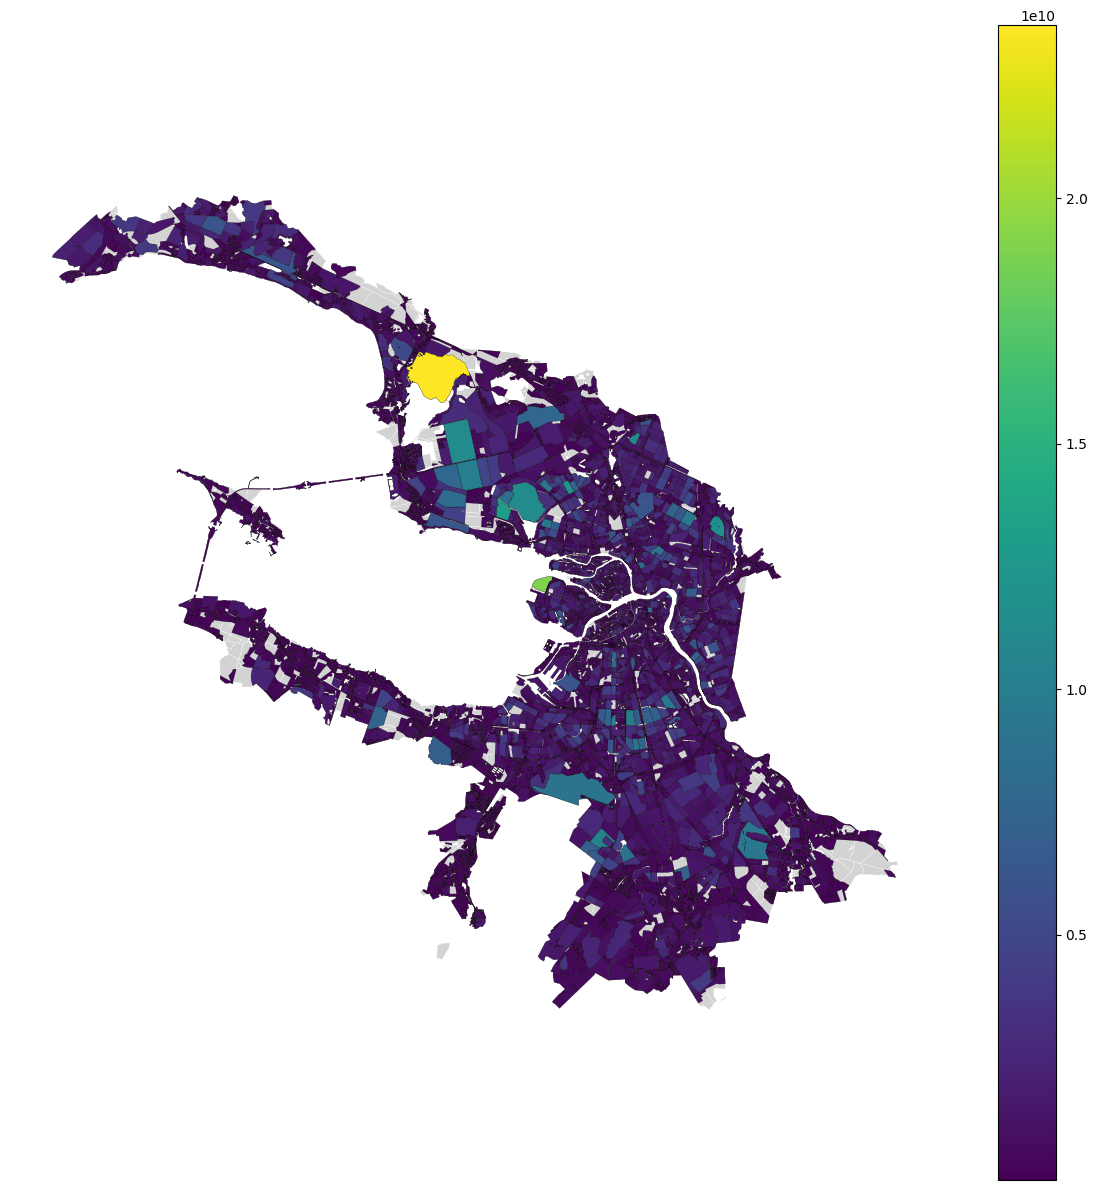

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 15))

# Все кварталы серым фоном
blocks.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)

# Отфильтрованные поверх с раскраской по land_value_per_sqm
blocks_clean.plot(
    ax=ax,
    column="land_value",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.2
)

ax.axis("off")
plt.show()

In [71]:
import pandas as pd

col = "land_use"

# Кол-во по land_use в blocks
cnt_blocks = (
    blocks[col]
    .value_counts(dropna=False)
    .rename("count_blocks")
)

# Кол-во по land_use в blocks_clean
cnt_blocks_clean = (
    blocks_clean[col]
    .value_counts(dropna=False)
    .rename("count_blocks_clean")
)

# Объединяем в одну таблицу
land_use_counts = (
    pd.concat([cnt_blocks, cnt_blocks_clean], axis=1)
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": col})
    .sort_values(col, na_position="last")
)

display(land_use_counts)


,land_use,count_blocks,count_blocks_clean
5,AGRICULTURE,142,119
4,BUSINESS,309,270
3,INDUSTRIAL,501,447
1,RECREATION,1671,1065
0,RESIDENTIAL,4919,4207
6,SPECIAL,126,102
2,TRANSPORT,1049,807


In [45]:
# import osmnx as ox
# import geopandas as gpd

# # 1) Граница Санкт-Петербурга
# city = ox.geocode_to_gdf("Saint Petersburg, Russia")
# city_polygon = city.geometry.iloc[0]

# # 2) Загружаем административные границы уровня 5
# tags = {
#     "boundary": "administrative",
#     "admin_level": "5",
# }

# districts = ox.features_from_polygon(city_polygon, tags=tags).reset_index()

# # 3) Оставляем только полигональные геометрии
# districts = districts[districts.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

# # 4) Полезные поля
# keep_cols = [
#     c for c in [
#         "name",
#         "name:ru",
#         "official_name",
#         "boundary",
#         "admin_level",
#         "wikidata",
#         "geometry",
#     ]
#     if c in districts.columns
# ]

# districts = districts[keep_cols].drop_duplicates().reset_index(drop=True)


# districts = districts[districts["admin_level"] == "5"].copy()
# districts = districts.iloc[:-1].copy()

# districts 



In [46]:
# districts.to_file("../data/traning_data/districts_spb.geojson", driver="GeoJSON")

In [47]:
districts = gpd.read_file('../data/traning_data/districts_spb.geojson')
districts

,name,name:ru,official_name,boundary,admin_level,wikidata,geometry
0,Колпинский район,Колпинский район,None,administrative,5,Q1326302,"POLYGON ((30.44112 59.82937, 30.44333 59.8298,..."
1,Пушкинский район,Пушкинский район,None,administrative,5,Q220316,"POLYGON ((30.21822 59.67307, 30.21918 59.67361..."
2,Московский район,Московский район,None,administrative,5,Q270112,"POLYGON ((30.19877 59.80161, 30.19901 59.8018,..."
3,Красносельский район,Красносельский район,None,administrative,5,Q270124,"MULTIPOLYGON (((30.06517 59.67798, 30.07283 59..."
4,Петродворцовый район,Петродворцовый район,None,administrative,5,Q270114,"MULTIPOLYGON (((30.04464 59.8635, 30.04455 59...."
5,Невский район,Невский район,None,administrative,5,Q1193156,"POLYGON ((30.36331 59.91387, 30.36951 59.91412..."
6,Фрунзенский район,Фрунзенский район,None,administrative,5,Q1142777,"POLYGON ((30.33258 59.91305, 30.33352 59.91337..."
7,Адмиралтейский район,Адмиралтейский район,None,administrative,5,Q219746,"POLYGON ((30.25023 59.90129, 30.25028 59.90132..."
8,Василеостровский район,Василеостровский район,None,administrative,5,Q220622,"POLYGON ((30.18468 59.95472, 30.18473 59.95481..."
9,Выборгский район,Выборгский район,None,administrative,5,Q219907,"POLYGON ((30.0729 60.09727, 30.08512 60.10426,..."


In [78]:
import geopandas as gpd

# districts — GeoDataFrame с полигонами районов из OSM
# blocks_clean — GeoDataFrame с кварталами

# 1) Выбираем колонку с названием района
district_name_col = "name:ru" if "name:ru" in districts.columns else "name"

districts_for_join = districts[[district_name_col, "geometry"]].copy()
districts_for_join = districts_for_join.rename(columns={district_name_col: "district_name"})

# 2) Приводим CRS
districts_for_join = districts_for_join.to_crs(blocks_clean.crs)

# 3) Для кварталов берём внутреннюю точку, чтобы не было дублей на границах
blocks_points = blocks_clean.copy()
blocks_points["geometry"] = blocks_points.geometry.representative_point()

# 4) Spatial join
joined = gpd.sjoin(
    blocks_points[["geometry"]],
    districts_for_join,
    how="left",
    predicate="within",
)

# 5) Добавляем атрибут района обратно в blocks_clean
blocks_clean = blocks_clean.copy()
blocks_clean["district_name"] = joined["district_name"]

# 6) Проверка
display(blocks_clean[["district_name", "geometry"]].head())
print("Missing district_name:", blocks_clean["district_name"].isna().sum())


,district_name,geometry
0,Московский район,"POLYGON ((352083.617 6633950.146, 352240.448 6..."
1,Пушкинский район,"POLYGON ((346700.642 6618453.176, 346681.107 6..."
2,Пушкинский район,"POLYGON ((347043.363 6618261.219, 347042.608 6..."
3,Пушкинский район,"POLYGON ((354879.039 6618859.116, 354845.405 6..."
4,Василеостровский район,"POLYGON ((347215.933 6646341.789, 347245.429 6..."


Missing district_name: 0


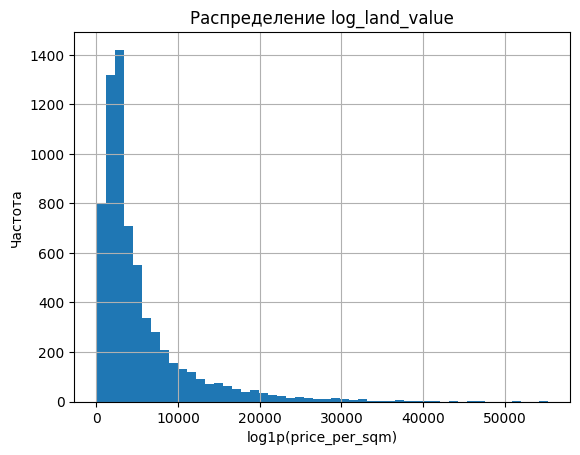

In [79]:

# Гистограмма
plt.figure()
blocks_clean['land_value_per_sqm'].hist(bins=50)
plt.xlabel('log1p(price_per_sqm)')
plt.ylabel('Частота')
plt.title('Распределение log_land_value')
plt.show()

land_value_per_sqm                1.000000
log_land_value_per_sqm            0.851114
fsi                               0.720431
gsi                               0.624793
l                                 0.509522
share_non_living                  0.430834
log_land_value                    0.430281
share_living                      0.423031
land_value_class_soft_expected    0.356370
land_value_class_pred             0.351645
land_value_class_soft_3           0.345208
residential                       0.326484
land_value                        0.322420
living_area                       0.280967
build_floor_area                  0.271434
population                        0.222822
non_living_area                   0.206717
mxi                               0.202856
footprint_area                    0.116891
land_value_class_soft_2           0.015708
business                          0.006207
osr                              -0.043206
share                            -0.045560
special    

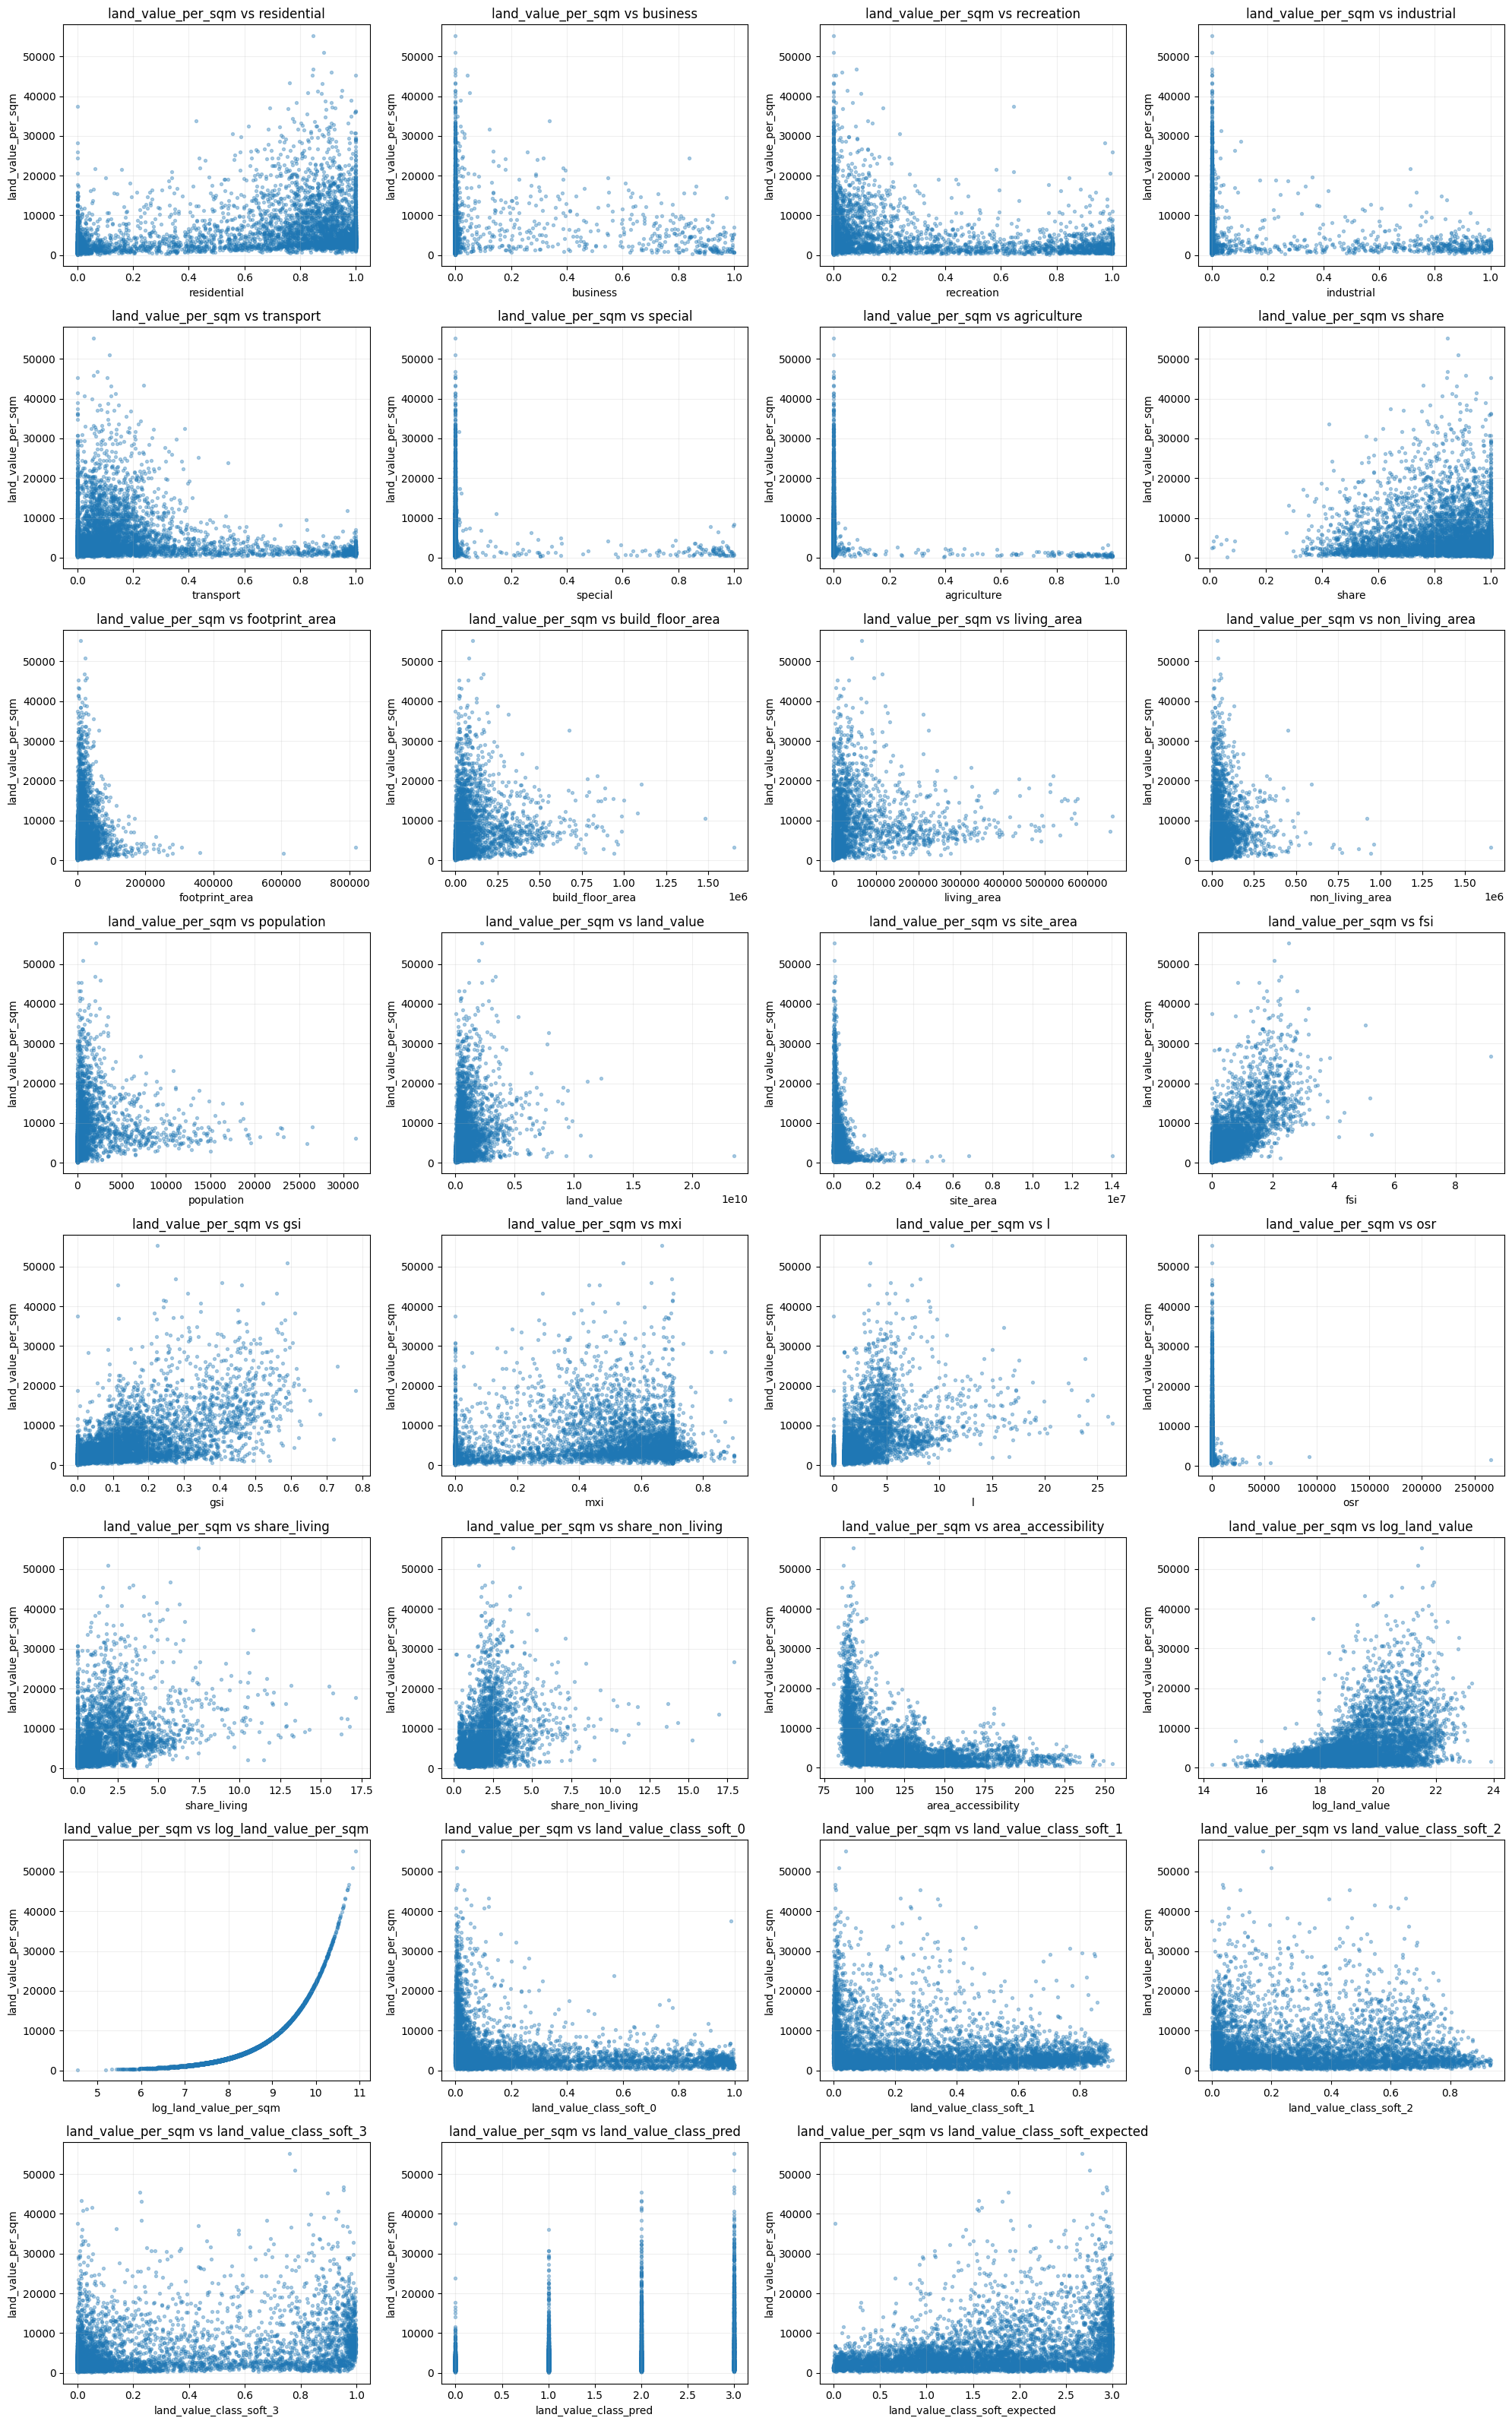

In [80]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

target_col = "land_value_per_sqm"
num_cols = [c for c in blocks_clean.columns if pd.api.types.is_numeric_dtype(blocks_clean[c])]
corr_to_target = (
    blocks_clean[num_cols]
    .corr(method="pearson")[target_col]
    .dropna()
    .sort_values(ascending=False)
)
display(corr_to_target)

# Целевая переменная
target_col = "land_value_per_sqm"

# Берем все фичи кроме target и geometry
exclude = {target_col, "geometry"}
feature_cols = [c for c in blocks_clean.columns if c not in exclude]

# Числовые фичи для scatter
num_features = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(blocks_clean[c])
]

# Подготовка
n = len(num_features)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
axes = axes.flatten()

for i, col in enumerate(num_features):
    tmp = blocks_clean[[col, target_col]].dropna()
    axes[i].scatter(tmp[col], tmp[target_col], s=8, alpha=0.35)
    axes[i].set_title(f"{target_col} vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)
    axes[i].grid(alpha=0.2)

# Удаляем пустые оси
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [81]:
q = blocks_clean["land_value_per_sqm"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["land_value_per_sqm"] < q].copy()
q = blocks_clean["footprint_area"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["footprint_area"] < q].copy()
q = blocks_clean["land_value"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["land_value"] < q].copy()
q = blocks_clean["osr"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["osr"] < q].copy()
q = blocks_clean["fsi"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["fsi"] < q].copy()
q = blocks_clean["site_area"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["site_area"] < q].copy()
q = blocks_clean["living_area"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["living_area"] < q].copy()
q = blocks_clean["non_living_area"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["non_living_area"] < q].copy()
q = blocks_clean["share_living"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["share_living"] < q].copy()
q = blocks_clean["share_non_living"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["share_non_living"] < q].copy()
q = blocks_clean["population"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["population"] < q].copy()

In [82]:
# === Simple train/test training (без фолдов) ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.metrics import r2_score
import numpy as np
from catboost import CatBoostRegressor, Pool
from urbanomy.methods.land_value_modeling.training_utils import (
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
)

# 1) Настройки
target_col = "land_value_per_sqm"   # как в твоем ноутбуке
radius_list = [300, 500, 1000, 2000, 3000]
test_size = 0.1
seed = 42
use_services = False

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    # 'land_value_class_soft_0',
    # 'land_value_class_soft_1',
    # 'land_value_class_soft_2',
    # 'land_value_class_soft_3',
    # 'land_value_class_soft_4',
    # 'land_value_class_pred',
    "land_value_class_soft_expected",
    'district_name',
}
cat_features = [c for c in ["land_use", "morphotype", ] if c in blocks_clean.columns]

def is_service_col(col: str) -> bool:
    return col.lower().startswith("count_")

# 2) Базовые признаки
feature_cols = []
for c in blocks_clean.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

# 3) Подготовка данных + lag-фичи на всем датасете
data_df = blocks_clean.copy()


for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

numeric_feats = [c for c in feature_cols if c not in cat_features and c != target_col and c in data_df.columns]

weights = build_radii_weights(data_df, radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys([c for c in feature_cols if c in data_lag.columns] + cat_features))
feats = feature_names(data_lag, base_cols_for_model, target_col)

# 4) Один train/test split (без кросс-валидации)
idx_train, idx_test = train_test_split(
    data_lag.index,
    test_size=test_size,
    random_state=seed,
    shuffle=True,
)

df_train = data_lag.loc[idx_train].copy()
df_test = data_lag.loc[idx_test].copy()

train_pool = Pool(df_train[feats], label=df_train[target_col], cat_features=cat_features, feature_names=feats)
test_pool = Pool(df_test[feats], label=df_test[target_col], cat_features=cat_features, feature_names=feats)

# 5) Обучение
model = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=20000,
    od_type="Iter",
    od_wait=2000,
    random_seed=seed,
    verbose=200,
)

model.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=600,
    use_best_model=True,
)

# 6) Метрики на train и test в оригинальной шкале
# --- Train ---
y_train_pred_raw = np.asarray(model.predict(df_train[feats])).reshape(-1)
y_train_true_raw = df_train[target_col].to_numpy()

y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

train_mape = mape(y_train_true, y_train_pred)
train_wape = wape(y_train_true, y_train_pred)
train_r2 = r2_score(y_train_true, y_train_pred)
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# --- Test ---
y_test_pred_raw = np.asarray(model.predict(df_test[feats])).reshape(-1)
y_test_true_raw = df_test[target_col].to_numpy()

y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

test_mape = mape(y_test_true, y_test_pred)
test_wape = wape(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

print("Train metrics:")
print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
print(f"MAE:  {train_mae:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"R2:   {train_r2:.6f}")

print("\nTest metrics:")
print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
print(f"MAE:  {test_mae:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"R2:   {test_r2:.6f}")

0:	learn: 3047.1151509	test: 3048.7479257	best: 3048.7479257 (0)	total: 8.3ms	remaining: 2m 45s
200:	learn: 1364.5039981	test: 1500.5829127	best: 1500.5829127 (200)	total: 1.18s	remaining: 1m 55s
400:	learn: 1198.1102078	test: 1428.7539352	best: 1428.7539352 (400)	total: 2.3s	remaining: 1m 52s
600:	learn: 1083.2135206	test: 1392.7007507	best: 1392.6285726 (597)	total: 3.43s	remaining: 1m 50s
800:	learn: 1012.6207613	test: 1375.6695875	best: 1375.6695875 (800)	total: 4.51s	remaining: 1m 48s
1000:	learn: 960.6287296	test: 1365.2821054	best: 1364.8553884 (981)	total: 5.68s	remaining: 1m 47s
1200:	learn: 914.5640630	test: 1357.0057516	best: 1357.0057516 (1200)	total: 6.78s	remaining: 1m 46s
1400:	learn: 869.7205848	test: 1349.2018430	best: 1349.1389575 (1391)	total: 7.91s	remaining: 1m 45s
1600:	learn: 834.6740442	test: 1342.5621899	best: 1342.5621899 (1600)	total: 9.07s	remaining: 1m 44s
1800:	learn: 807.1963877	test: 1337.6484787	best: 1337.4777083 (1796)	total: 10.2s	remaining: 1m 43s
2

In [88]:
import re
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) Разбиваем фичи на base / lag-группы по радиусам
lag_groups = {r: [] for r in radius_list}
other_lag_feats = []
base_feats = []

for f in feats:
    matched = False
    for r in radius_list:
        if f.startswith(f"lag{r}_"):
            lag_groups[r].append(f)
            matched = True
            break

    if matched:
        continue

    if f.startswith("lag"):
        other_lag_feats.append(f)
    else:
        base_feats.append(f)

print("Base feats:", len(base_feats))
for r in radius_list:
    print(f"Lag feats radius {r}: {len(lag_groups[r])}")
print("Other lag feats:", len(other_lag_feats))



# 2) Универсальная функция оценки
def evaluate_feature_set(feature_set, name):
    feature_set = list(dict.fromkeys(feature_set))
    feature_set = [f for f in feature_set if f in df_train.columns and f in df_test.columns]
    cat_subset = [c for c in cat_features if c in feature_set]

    train_pool = Pool(
        df_train[feature_set],
        label=df_train[target_col],
        cat_features=cat_subset,
        feature_names=feature_set,
    )
    test_pool = Pool(
        df_test[feature_set],
        label=df_test[target_col],
        cat_features=cat_subset,
        feature_names=feature_set,
    )

    model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        iterations=5000,
        od_type="Iter",
        od_wait=300,
        random_seed=seed,
        verbose=False,
    )

    model.fit(
        train_pool,
        eval_set=test_pool,
        early_stopping_rounds=300,
        use_best_model=True,
        verbose=False,
    )

    y_train_pred_raw = np.asarray(model.predict(df_train[feature_set])).reshape(-1)
    y_test_pred_raw = np.asarray(model.predict(df_test[feature_set])).reshape(-1)

    y_train_true_raw = df_train[target_col].to_numpy()
    y_test_true_raw = df_test[target_col].to_numpy()

    y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
    y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

    y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
    y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

    return {
        "set_name": name,
        "n_features": len(feature_set),
        "best_iteration": model.get_best_iteration() + 1 if model.get_best_iteration() is not None else None,
        "train_mape": mape(y_train_true, y_train_pred),
        "train_wape": wape(y_train_true, y_train_pred),
        "train_mae": mean_absolute_error(y_train_true, y_train_pred),
        "train_rmse": np.sqrt(mean_squared_error(y_train_true, y_train_pred)),
        "train_r2": r2_score(y_train_true, y_train_pred),
        "test_mape": mape(y_test_true, y_test_pred),
        "test_wape": wape(y_test_true, y_test_pred),
        "test_mae": mean_absolute_error(y_test_true, y_test_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test_true, y_test_pred)),
        "test_r2": r2_score(y_test_true, y_test_pred),
        "features": feature_set,
        "model": model,
    }

# 3) Наборы для ablation
candidate_sets = {
    "base_only": base_feats,
}

for r in radius_list:
    candidate_sets[f"base_plus_r{r}"] = base_feats + lag_groups[r]

cumulative = []
for r in radius_list:
    cumulative = cumulative + lag_groups[r]
    candidate_sets[f"base_plus_to_r{r}"] = base_feats + cumulative

if len(other_lag_feats) > 0:
    candidate_sets["base_plus_other_lags"] = base_feats + other_lag_feats
    candidate_sets["all_features"] = base_feats + cumulative + other_lag_feats
else:
    candidate_sets["all_features"] = base_feats + cumulative

# 4) Прогон
ablation_results = []
ablation_models = {}

for name, feature_set in candidate_sets.items():
    res = evaluate_feature_set(feature_set, name)
    ablation_models[name] = res["model"]
    ablation_results.append({k: v for k, v in res.items() if k not in ["features", "model"]})

ablation_df = (
    pd.DataFrame(ablation_results)
    .sort_values(["test_mae", "test_wape", "test_rmse"], ascending=True)
    .reset_index(drop=True)
)

display(ablation_df)

best_ablation_name = ablation_df.iloc[0]["set_name"]
print("Best ablation set:", best_ablation_name)


Base feats: 31
Lag feats radius 300: 24
Lag feats radius 500: 24
Lag feats radius 1000: 24
Lag feats radius 2000: 24
Lag feats radius 3000: 24
Other lag feats: 0


,set_name,n_features,best_iteration,train_mape,train_wape,train_mae,train_rmse,train_r2,test_mape,test_wape,test_mae,test_rmse,test_r2
0,base_plus_r3000,55,4858,0.105854,0.122333,633.370058,1443.906631,0.913090,0.260868,0.243508,1269.082852,2182.725341,0.802230
1,base_plus_r2000,55,4530,0.107385,0.126606,655.494682,1507.815091,0.905226,0.268914,0.248127,1293.155965,2242.612616,0.791229
2,base_plus_to_r2000,127,4345,0.095589,0.117567,608.694078,1457.656863,0.911426,0.279452,0.248937,1297.372904,2236.510586,0.792363
3,base_plus_to_r3000,151,4818,0.091820,0.115642,598.729834,1435.726172,0.914072,0.278425,0.251601,1311.257793,2268.012851,0.786473
4,all_features,151,4818,0.091820,0.115642,598.729834,1435.726172,0.914072,0.278425,0.251601,1311.257793,2268.012851,0.786473
5,base_plus_r1000,55,4990,0.103798,0.122040,631.852346,1463.122355,0.910761,0.280969,0.257487,1341.937046,2288.083469,0.782677
6,base_plus_to_r1000,103,3760,0.103578,0.124685,645.545662,1497.965296,0.906460,0.295830,0.260629,1358.309422,2303.086388,0.779817
7,base_plus_r500,55,5000,0.103210,0.121438,628.738647,1479.196328,0.908789,0.293185,0.261181,1361.188098,2304.181190,0.779608
8,base_plus_to_r500,79,4934,0.101778,0.116677,604.084636,1425.517646,0.915289,0.299840,0.261493,1362.812813,2295.977036,0.781175
9,base_only,31,4479,0.131388,0.143333,742.094185,1625.121055,0.889906,0.283274,0.261521,1362.960633,2276.753428,0.784824


Best ablation set: base_plus_r3000


In [ ]:
selected_features = candidate_sets["base_plus_r3000"]


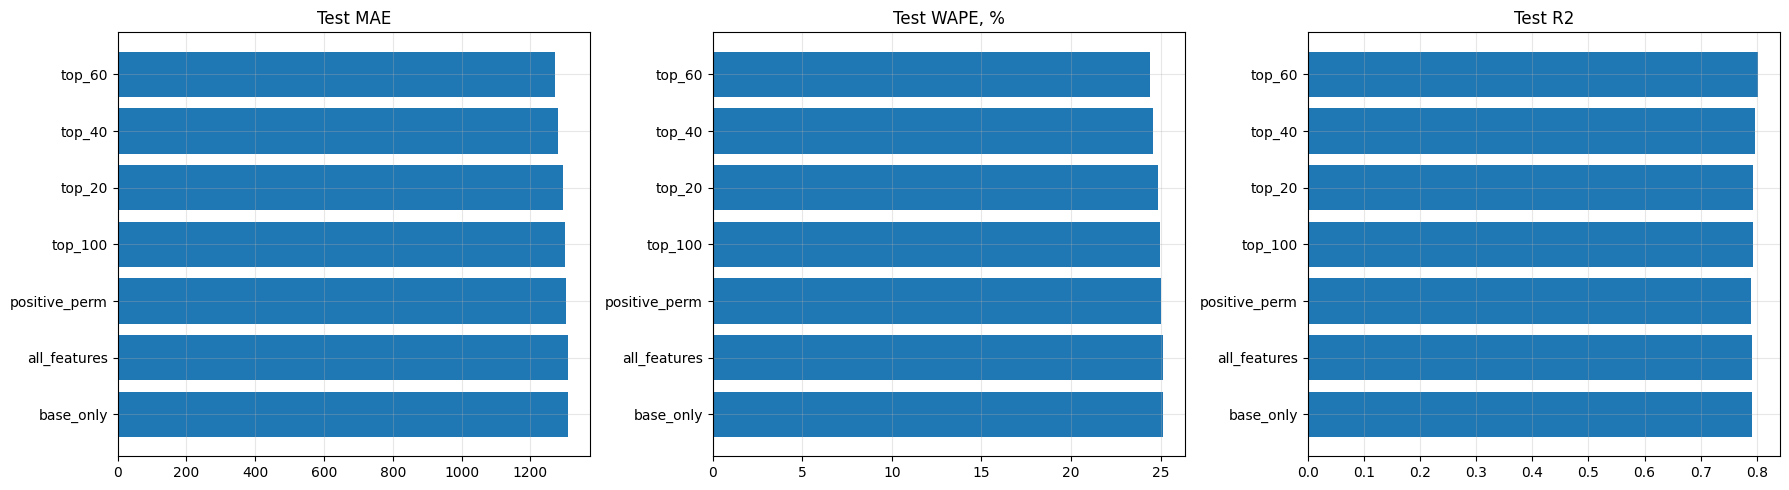

In [89]:
import matplotlib.pyplot as plt

plot_df = results_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(plot_df["set_name"], plot_df["test_mae"])
axes[0].invert_yaxis()
axes[0].set_title("Test MAE")
axes[0].grid(alpha=0.3)

axes[1].barh(plot_df["set_name"], plot_df["test_wape"] * 100)
axes[1].invert_yaxis()
axes[1].set_title("Test WAPE, %")
axes[1].grid(alpha=0.3)

axes[2].barh(plot_df["set_name"], plot_df["test_r2"])
axes[2].invert_yaxis()
axes[2].set_title("Test R2")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [93]:
# === Simple train/test training with selected features ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from catboost import CatBoostRegressor, Pool
from urbanomy.methods.land_value_modeling.training_utils import (
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
)

# 1) Настройки
target_col = "land_value_per_sqm"
radius_list = [300, 500, 1000, 2000, 3000]
test_size = 0.1
seed = 42
use_services = False

# Сюда можно передать отобранные фичи, например:
# selected_features = top_60_features
selected_features = None

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    "land_value_class_soft_expected",
    "district_name",
}

cat_features = [c for c in ["land_use", "morphotype"] if c in blocks_clean.columns]

def is_service_col(col: str) -> bool:
    return col.lower().startswith("count_")

# 2) Базовые признаки
feature_cols = []
for c in blocks_clean.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

# 3) Подготовка данных + lag-фичи
data_df = blocks_clean.copy()

for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

numeric_feats = [
    c for c in feature_cols
    if c not in cat_features and c != target_col and c in data_df.columns
]

weights = build_radii_weights(data_df, radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(
    [c for c in feature_cols if c in data_lag.columns] + cat_features
))
all_feats = feature_names(data_lag, base_cols_for_model, target_col)

selected_features = candidate_sets["base_plus_r3000"]

# 4) Выбор фичей для обучения
if selected_features is None:
    feats = all_feats
else:
    feats = [f for f in selected_features if f in all_feats]
    if len(feats) == 0:
        raise ValueError("selected_features is empty after filtering by available model features")

cat_features_model = [c for c in cat_features if c in feats]

print(f"Total available features: {len(all_feats)}")
print(f"Selected features for training: {len(feats)}")

# 5) Train/test split
idx_train, idx_test = train_test_split(
    data_lag.index,
    test_size=test_size,
    random_state=seed,
    shuffle=True,
)

df_train = data_lag.loc[idx_train].copy()
df_test = data_lag.loc[idx_test].copy()

train_pool = Pool(
    df_train[feats],
    label=df_train[target_col],
    cat_features=cat_features_model,
    feature_names=feats,
)
test_pool = Pool(
    df_test[feats],
    label=df_test[target_col],
    cat_features=cat_features_model,
    feature_names=feats,
)

# 6) Обучение
model = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=20000,
    od_type="Iter",
    od_wait=2000,
    random_seed=seed,
    verbose=200,
)

model.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=600,
    use_best_model=True,
)

# 7) Метрики на train/test в оригинальной шкале
# --- Train ---
y_train_pred_raw = np.asarray(model.predict(df_train[feats])).reshape(-1)
y_train_true_raw = df_train[target_col].to_numpy()

y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

train_mape = mape(y_train_true, y_train_pred)
train_wape = wape(y_train_true, y_train_pred)
train_r2 = r2_score(y_train_true, y_train_pred)
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# --- Test ---
y_test_pred_raw = np.asarray(model.predict(df_test[feats])).reshape(-1)
y_test_true_raw = df_test[target_col].to_numpy()

y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

test_mape = mape(y_test_true, y_test_pred)
test_wape = wape(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

print("Train metrics:")
print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
print(f"MAE:  {train_mae:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"R2:   {train_r2:.6f}")

print("\nTest metrics:")
print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
print(f"MAE:  {test_mae:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"R2:   {test_r2:.6f}")


Total available features: 151
Selected features for training: 55
0:	learn: 3050.7296092	test: 3043.9532527	best: 3043.9532527 (0)	total: 6.18ms	remaining: 2m 3s
200:	learn: 1358.1073545	test: 1466.9654128	best: 1466.9654128 (200)	total: 734ms	remaining: 1m 12s
400:	learn: 1199.9915316	test: 1395.8388041	best: 1395.8388041 (400)	total: 1.38s	remaining: 1m 7s
600:	learn: 1100.1193614	test: 1359.6556439	best: 1359.6556439 (600)	total: 2.04s	remaining: 1m 5s
800:	learn: 1025.2902230	test: 1339.1030518	best: 1339.1030518 (800)	total: 2.75s	remaining: 1m 5s
1000:	learn: 969.5750152	test: 1328.7600835	best: 1328.7600835 (1000)	total: 3.41s	remaining: 1m 4s
1200:	learn: 927.4176367	test: 1320.9896322	best: 1320.8643385 (1198)	total: 4.06s	remaining: 1m 3s
1400:	learn: 897.7207254	test: 1315.4644983	best: 1315.4644983 (1400)	total: 4.74s	remaining: 1m 2s
1600:	learn: 865.6066783	test: 1309.5474533	best: 1309.0247450 (1589)	total: 5.43s	remaining: 1m 2s
1800:	learn: 841.0553487	test: 1306.867879

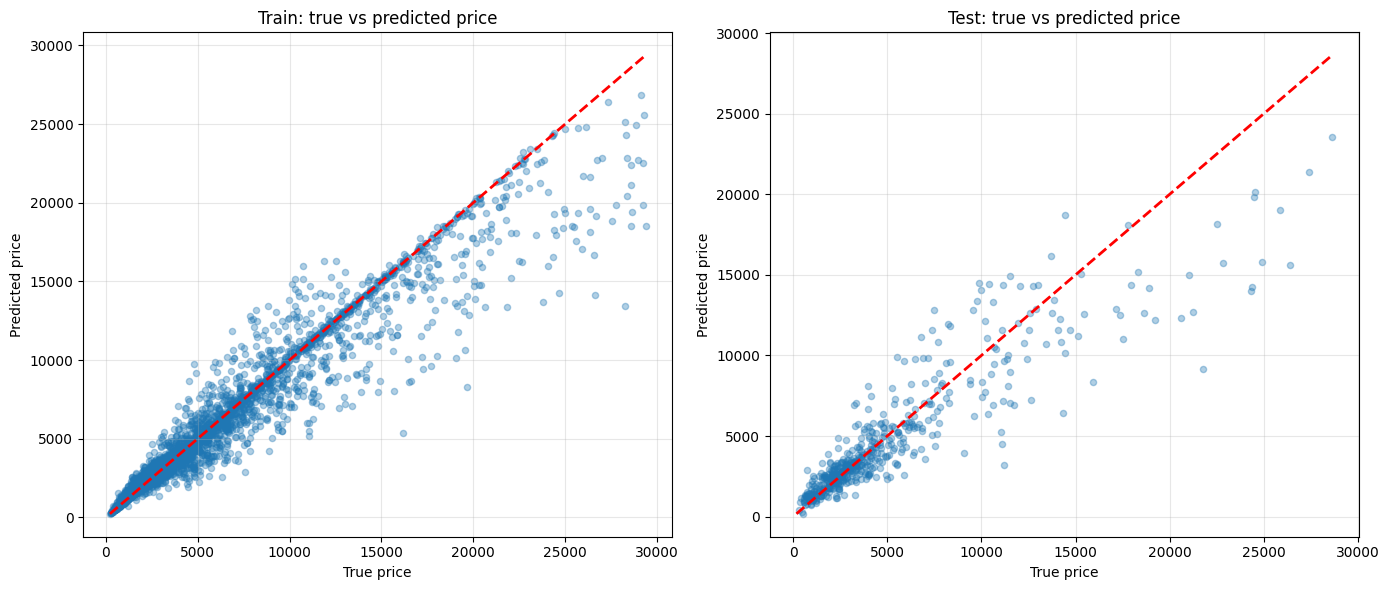

In [95]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

# Train
axes[0].scatter(y_train_true, y_train_pred, alpha=0.35, s=20)
mn = min(y_train_true.min(), y_train_pred.min())
mx = max(y_train_true.max(), y_train_pred.max())
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=2)
axes[0].set_title("Train: true vs predicted price")
axes[0].set_xlabel("True price")
axes[0].set_ylabel("Predicted price")
axes[0].grid(alpha=0.3)

# Test
axes[1].scatter(y_test_true, y_test_pred, alpha=0.35, s=20)
mn = min(y_test_true.min(), y_test_pred.min())
mx = max(y_test_true.max(), y_test_pred.max())
axes[1].plot([mn, mx], [mn, mx], "r--", linewidth=2)
axes[1].set_title("Test: true vs predicted price")
axes[1].set_xlabel("True price")
axes[1].set_ylabel("Predicted price")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Основное обучение

In [31]:
from urbanomy.methods.land_value_modeling.training_utils import TrainingConfig, run_training
import logging

# Флаг: учить с сервисами (count_*) или без
use_services = False   # False -> исключаем все count_* фичи

target_col = "land_value_per_sqm"
radius_list = [300, 500, 1000, 2000, 3000]

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    'land_value_class_soft_expected',
    'district_name',
}

def is_service_col(col: str) -> bool:
    # сервисы у тебя обычно в формате count_...
    # если есть другие варианты (например Count_ / COUNT_), делаем lower()
    c = col.lower()
    return c.startswith("count_")

# формируем feature_cols с учетом флага
feature_cols = []
for c in blocks.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

cat_features = ["land_use", "morphotype", 'land_value_class_pred',]

cfg = TrainingConfig(
    feature_cols=feature_cols,
    cat_features=cat_features,
    radius_list=radius_list,
    target_col=target_col,
    group_col="district_name",
    loss_function="MAE",
    eval_metric="MAE",
    hpo_iter=1,
    param_grid={
        "depth": [6],
        "learning_rate": [0.03],
        "l2_leaf_reg": [3],
        "random_strength": [1.0],
        "bagging_temperature": [1.0],
    },
    # n_clusters=20,
    inner_splits=5,
    outer_splits=5,
    iterations=20000,
    od_wait=2000,
    seed=42,
)

model, metrics = run_training(
    blocks_clean,
    cfg,
    log_path=f"catboost_info/training_{'with_services' if use_services else 'no_services'}.log",
    console_level=logging.WARNING,
)

print("use_services =", use_services)
print(metrics)
 

OuterCV:   0%|          | 0/5 [00:00<?, ?it/s]

Trials:   0%|          | 0/1 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

0:	learn: 3016.3789910	total: 6.38ms	remaining: 4.39s
200:	learn: 1401.3352569	total: 1.32s	remaining: 3.19s
400:	learn: 1262.2457794	total: 2.62s	remaining: 1.88s
600:	learn: 1165.0031875	total: 3.92s	remaining: 567ms
687:	learn: 1129.9548169	total: 4.51s	remaining: 0us
2026-03-03 15:24:54,347 | WARNING | Train metrics:
MAPE: 0.223430 (22.34%)
WAPE: 0.222336 (22.23%)
MAE:  1131.313523
RMSE: 2183.696693
R2:   0.798186

Test metrics:
MAPE: 0.415931 (41.59%)
WAPE: 0.340791 (34.08%)
MAE:  1731.242564
RMSE: 2802.473330
R2:   0.599178
use_services = False
{'r2': 0.599177956509114, 'r2_std': 0.07933672330013218, 'mae': 1731.2425643670645, 'mae_std': 426.6776790406584, 'rmse': 2802.473330024835, 'rmse_std': 674.6470388986884, 'nrmse': 0.09748807358864289, 'nrmse_std': 0.023170303937225956, 'mean_error': -385.7108184707428, 'mean_error_std': 600.866227778509, 'mpe': 16.7656061984216, 'mpe_std': 15.537122924208472, 'mape': 41.59309348327169, 'mape_std': 5.970262670424363, 'wape': 34.07908873928

In [32]:
district_counts = (
    blocks_clean
    .assign(district_name=blocks_clean["district_name"].astype("string").fillna("missing"))
    .groupby("district_name", dropna=False)
    .size()
    .reset_index(name="n_blocks")
    .sort_values("n_blocks", ascending=False)
)

display(district_counts)


,district_name,n_blocks
9,Курортный район,733
7,Красносельский район,656
15,Пушкинский район,627
14,Приморский район,484
13,Петродворцовый район,452
2,Выборгский район,382
5,Колпинский район,263
17,Центральный район,226
11,Невский район,214
6,Красногвардейский район,214


In [33]:
from sklearn.model_selection import GroupKFold
import pandas as pd

groups = pd.factorize(blocks_clean["district_name"].astype("string").fillna("missing_group"))[0]
gkf = GroupKFold(n_splits=cfg.outer_splits)

for i, (train_idx, test_idx) in enumerate(
    gkf.split(blocks_clean, blocks_clean[cfg.target_col], groups), 1
):
    print(f"Fold {i}")
    print(f"  train rows: {len(train_idx)}")
    print(f"  test rows:  {len(test_idx)}")
    print(f"  train districts: {len(set(groups[train_idx]))}")
    print(f"  test districts:  {len(set(groups[test_idx]))}")


Fold 1
  train rows: 4382
  test rows:  1076
  train districts: 15
  test districts:  3
Fold 2
  train rows: 4321
  test rows:  1137
  train districts: 14
  test districts:  4
Fold 3
  train rows: 4409
  test rows:  1049
  train districts: 15
  test districts:  3
Fold 4
  train rows: 4395
  test rows:  1063
  train districts: 14
  test districts:  4
Fold 5
  train rows: 4325
  test rows:  1133
  train districts: 14
  test districts:  4


In [96]:
# === SHAP: beeswarm + bar для текущей модели ===
import shap

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
    feature_names,
)

target_col = cfg.target_col

numeric_feats = [
    c for c in cfg.feature_cols
    if c not in cfg.cat_features and c != target_col and c in blocks_clean.columns
]

work_df = blocks_clean.copy()
prep_cat_inplace(work_df, cfg.cat_features)

weights_shap = build_radii_weights(work_df, cfg.radius_list)
data_lag_shap = add_lags_full_df(work_df, weights=weights_shap, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(list(cfg.feature_cols) + list(cfg.cat_features)))
feats = feature_names(data_lag_shap, base_cols_for_model, target_col)

X_shap = data_lag_shap[feats]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# 1) Beeswarm
shap.summary_plot(shap_values, X_shap, feature_names=feats, show=True)



CatBoostError: catboost/libs/data/model_dataset_compatibility.cpp:81: At position 26 should be feature with name n_neighbors_300 (found lag300_residential).

In [ ]:
# === Inference + метрики для текущей модели ===
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
    rmse,
)

target_col = cfg.target_col

# 1) Восстанавливаем тот же набор числовых фич, что использовался при обучении
numeric_feats = [
    c for c in cfg.feature_cols
    if c not in cfg.cat_features and c != target_col and c in blocks_clean.columns
]

# 2) Готовим данные и считаем лаги так же, как в run_training
work_df = blocks_clean.copy()
prep_cat_inplace(work_df, cfg.cat_features)

weights_inf = build_radii_weights(work_df, cfg.radius_list)
data_lag_inf = add_lags_full_df(work_df, weights=weights_inf, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(list(cfg.feature_cols) + list(cfg.cat_features)))
feats = feature_names(data_lag_inf, base_cols_for_model, target_col)

# 3) Проверка фичей
missing_feats = [c for c in feats if c not in data_lag_inf.columns]
if missing_feats:
    raise ValueError(
        f"Не хватает фичей для модели ({len(missing_feats)}): "
        f"{missing_feats[:20]}{' ...' if len(missing_feats) > 20 else ''}"
    )

# 4) Предсказание
y_pred_raw = np.asarray(model.predict(data_lag_inf[feats])).reshape(-1)
y_pred = to_original_scale(y_pred_raw, target_col=target_col)

out_df = data_lag_inf.copy()
out_df["pred_raw"] = y_pred_raw
out_df[f"{target_col}_pred"] = y_pred

# 5) Метрики
if target_col in out_df.columns:
    y_true_raw = out_df[target_col].to_numpy()
    y_true = to_original_scale(y_true_raw, target_col=target_col)

    out_df[f"{target_col}_true"] = y_true

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > 0)

    out_df["error_pct"] = np.nan
    out_df.loc[mask, "error_pct"] = (
        np.abs(y_pred[mask] - y_true[mask]) / np.abs(y_true[mask]) * 100.0
    )

    mape_val = mape(y_true[mask], y_pred[mask])
    wape_val = wape(y_true[mask], y_pred[mask])
    mae_val = mean_absolute_error(y_true[mask], y_pred[mask])
    rmse_val = rmse(y_true[mask], y_pred[mask])
    r2_val = r2_score(y_true[mask], y_pred[mask])

    print(f"Rows used in metrics: {mask.sum()} / {len(mask)}")
    print(f"MAPE: {mape_val:.6f} ({mape_val*100:.2f}%)")
    print(f"WAPE: {wape_val:.6f} ({wape_val*100:.2f}%)")
    print(f"MAE:  {mae_val:.6f}")
    print(f"RMSE: {rmse_val:.6f}")
    print(f"R2:   {r2_val:.6f}")

    display(out_df[[target_col, f"{target_col}_pred", "error_pct"]].head(20))

    out_df_over_10 = out_df[out_df["error_pct"] > 10].copy()
else:
    print(f"Column '{target_col}' not found -> predictions only.")
    display(out_df[[f"{target_col}_pred"]].head(20))


In [57]:
stats_by_landuse = (
    out_df
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        p90_error_pct=("error_pct", lambda s: s.quantile(0.90)),
        max_error_pct=("error_pct", "max"),
    )
    .sort_values("mean_error_pct", ascending=False)
)

display(stats_by_landuse)

,n,mean_error_pct,median_error_pct,p90_error_pct,max_error_pct
land_use,,,,,
AGRICULTURE,41,34.458658,23.250193,64.704431,194.232539
RECREATION,607,27.732788,17.935663,63.069751,223.621437
SPECIAL,67,24.079187,14.247690,53.002193,135.209279
TRANSPORT,530,22.662225,17.480273,46.174727,148.134025
INDUSTRIAL,337,19.494689,13.694827,42.603755,150.510385
BUSINESS,230,18.463603,10.865267,42.663828,104.238610
RESIDENTIAL,3309,15.337882,10.635261,33.137361,292.330822


In [58]:
out_df_over_100 = out_df[out_df["error_pct"] > 100]
out_df_100 = out_df[out_df["error_pct"] <= 100]

stats_by_landuse = (
    out_df_over_100
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        p90_error_pct=("error_pct", lambda s: s.quantile(0.90)),
        max_error_pct=("error_pct", "max"),
    )
)

stats_by_landuse["share_of_all_plots_pct"] = (
    stats_by_landuse["n"] / len(out_df) * 100
)

stats_by_landuse = stats_by_landuse.sort_values("mean_error_pct", ascending=False)

display(stats_by_landuse)


,n,mean_error_pct,median_error_pct,p90_error_pct,max_error_pct,share_of_all_plots_pct
land_use,,,,,,
AGRICULTURE,2,161.511298,161.511298,187.688290,194.232539,0.039055
RESIDENTIAL,10,149.000752,127.237814,219.516791,292.330822,0.195274
RECREATION,27,139.003946,134.163691,175.784204,223.621437,0.527241
INDUSTRIAL,2,135.571146,135.571146,147.522537,150.510385,0.039055
SPECIAL,2,124.132173,124.132173,132.993858,135.209279,0.039055
TRANSPORT,6,117.054818,106.133160,140.538145,148.134025,0.117165
BUSINESS,1,104.238610,104.238610,104.238610,104.238610,0.019527


In [59]:
# === Conformal interval по land_use ===
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

alpha = 0.10  # 90% PI
group_col = "land_use"
true_col = "land_value_per_sqm_true"
pred_col = "land_value_per_sqm_pred"

# 1) валидные строки
valid_mask = (
    np.isfinite(out_df[true_col].to_numpy()) &
    np.isfinite(out_df[pred_col].to_numpy()) &
    out_df[group_col].notna()
)
df_valid = out_df.loc[valid_mask].copy()

# 2) calibration / evaluation
idx_cal, idx_eval = train_test_split(
    df_valid.index, test_size=0.5, random_state=42, shuffle=True
)
cal_df = df_valid.loc[idx_cal].copy()
eval_df = df_valid.loc[idx_eval].copy()

# 3) глобальный q_hat (fallback)
abs_err_cal_all = np.abs(cal_df[pred_col] - cal_df[true_col]).to_numpy()
n_all = len(abs_err_cal_all)
k_all = int(np.ceil((n_all + 1) * (1 - alpha)))
k_all = min(max(k_all, 1), n_all)
q_hat_global = np.partition(abs_err_cal_all, k_all - 1)[k_all - 1]

# 4) q_hat по группам land_use
min_cal_size = 30  # если в группе мало точек, используем глобальный q_hat
qhat_by_group = {}

for g, gdf in cal_df.groupby(group_col):
    abs_err = np.abs(gdf[pred_col] - gdf[true_col]).to_numpy()
    n = len(abs_err)
    if n < min_cal_size:
        qhat_by_group[g] = q_hat_global
        continue
    k = int(np.ceil((n + 1) * (1 - alpha)))
    k = min(max(k, 1), n)
    qhat_by_group[g] = np.partition(abs_err, k - 1)[k - 1]

# 5) строим интервалы
q_series = out_df[group_col].map(qhat_by_group).fillna(q_hat_global)
out_df["q_hat_land_use"] = q_series

out_df["pi_lower"] = (out_df[pred_col] - out_df["q_hat_land_use"]).clip(lower=0)
out_df["pi_upper"] = out_df[pred_col] + out_df["q_hat_land_use"]

# 6) оценка покрытия на eval
eval_tmp = out_df.loc[idx_eval].copy()
covered_eval = (eval_tmp[true_col] >= eval_tmp["pi_lower"]) & (eval_tmp[true_col] <= eval_tmp["pi_upper"])

coverage_eval_total = covered_eval.mean() * 100
avg_width_eval_total = (eval_tmp["pi_upper"] - eval_tmp["pi_lower"]).mean()

print(f"Target coverage: {(1-alpha)*100:.1f}%")
print(f"Empirical coverage (eval, total): {coverage_eval_total:.2f}%")
print(f"Average interval width (eval, total): {avg_width_eval_total:.2f}")

# покрытие по land_use
coverage_by_landuse = (
    eval_tmp.assign(covered=covered_eval)
    .groupby(group_col)
    .agg(
        n=("covered", "size"),
        coverage_pct=("covered", lambda s: s.mean() * 100),
        avg_width=("pi_upper", lambda s: (s - eval_tmp.loc[s.index, "pi_lower"]).mean()),
        q_hat=("q_hat_land_use", "mean"),
    )
    .sort_values("coverage_pct")
)

display(coverage_by_landuse)
display(out_df[[group_col, true_col, pred_col, "pi_lower", "pi_upper", "q_hat_land_use"]].head(20))


Target coverage: 90.0%
Empirical coverage (eval, total): 91.37%
Average interval width (eval, total): 2584.16


,n,coverage_pct,avg_width,q_hat
land_use,,,,
RECREATION,306,85.947712,2199.415452,1118.876187
TRANSPORT,268,88.805970,1569.386505,791.956483
RESIDENTIAL,1655,91.963746,2836.043868,1418.904106
SPECIAL,29,93.103448,1692.386878,864.055105
BUSINESS,114,94.736842,2596.580511,1322.068424
INDUSTRIAL,171,95.906433,2594.073653,1318.183752
AGRICULTURE,18,100.000000,2337.869793,1332.134858


,land_use,land_value_per_sqm_true,land_value_per_sqm_pred,pi_lower,pi_upper,q_hat_land_use
0,AGRICULTURE,942.386203,1260.016122,0.000000,2592.150980,1332.134858
1,RESIDENTIAL,1952.414484,2147.212238,728.308132,3566.116344,1418.904106
2,RESIDENTIAL,1507.223306,1432.869896,13.965790,2851.774002,1418.904106
3,RESIDENTIAL,2197.747147,2612.778991,1193.874885,4031.683097,1418.904106
4,INDUSTRIAL,8603.688296,7757.928176,6439.744424,9076.111929,1318.183752
5,AGRICULTURE,1421.128598,1095.789438,0.000000,2427.924295,1332.134858
8,RESIDENTIAL,1160.558788,1486.549144,67.645039,2905.453250,1418.904106
9,RESIDENTIAL,3325.537139,3405.453022,1986.548916,4824.357127,1418.904106
14,TRANSPORT,1887.441927,1772.013954,980.057471,2563.970437,791.956483
15,RECREATION,2184.491359,2333.520188,1214.644001,3452.396374,1118.876187


In [25]:
# model_path = f"catboost_land_value_{'with_services' if use_services else 'no_services'}.cbm"
# model.save_model(model_path)
# print(model_path)

